In [1]:
import pickle

with open("NIOSH_Combined_Dataset.pkl", "rb") as f:
    loaded_data = pickle.load(f)

ts_data = loaded_data["ts_data"]
anthro_clean = loaded_data["anthro_clean"]
experiment_settings = loaded_data["experiment_settings"]

In [2]:
for name, data in [("ts_data", ts_data), ("anthro_clean", anthro_clean), ("experiment_settings", experiment_settings)]:
    print(f"--- {name} ---")
    print(f"Type: {type(data)}")
    if hasattr(data, 'shape'):
        print(f"Shape: {data.shape}")
    elif hasattr(data, 'keys'):
        print(f"Keys: {list(data.keys())}")
    elif isinstance(data, list):
        print(f"Length: {len(data)}")
    print()


--- ts_data ---
Type: <class 'dict'>
Keys: [('Sub01', 'Session1'), ('Sub01', 'Session2'), ('Sub01', 'Session3'), ('Sub01', 'Session4'), ('Sub02', 'Session1'), ('Sub02', 'Session2'), ('Sub02', 'Session3'), ('Sub02', 'Session4'), ('Sub03', 'Session1'), ('Sub03', 'Session2'), ('Sub03', 'Session3'), ('Sub03', 'Session4'), ('Sub04', 'Session1'), ('Sub04', 'Session2'), ('Sub04', 'Session3'), ('Sub04', 'Session4'), ('Sub05', 'Session1'), ('Sub05', 'Session2'), ('Sub05', 'Session3'), ('Sub05', 'Session4'), ('Sub06', 'Session1'), ('Sub06', 'Session2'), ('Sub06', 'Session3'), ('Sub06', 'Session4'), ('Sub07', 'Session1'), ('Sub07', 'Session2'), ('Sub07', 'Session3'), ('Sub07', 'Session4'), ('Sub08', 'Session1'), ('Sub08', 'Session2'), ('Sub08', 'Session3'), ('Sub08', 'Session4'), ('Sub09', 'Session1'), ('Sub09', 'Session2'), ('Sub09', 'Session3'), ('Sub09', 'Session4'), ('Sub10', 'Session1'), ('Sub10', 'Session2'), ('Sub10', 'Session3'), ('Sub10', 'Session4'), ('Sub11', 'Session1'), ('Sub12', 'Se

In [3]:
anthro_clean

,Subject,Gender,Age,Height (cm),Weight (kg),Waist circumference (cm),Hip circumference (cm)
0,Sub01,M,20,170.180,68.038855,84.328,93.98
1,Sub02,M,20,179.000,87.000000,90.000,107.00
2,Sub03,F,28,163.000,72.000000,69.000,112.00
3,Sub04,M,27,179.000,70.000000,83.500,93.00
4,Sub05,M,24,180.340,83.007404,74.930,81.28
5,Sub06,F,30,164.000,52.000000,71.000,98.00
6,Sub07,F,27,167.640,64.410117,99.060,104.14
7,Sub08,F,29,164.000,50.000000,66.040,87.63
8,Sub09,M,32,183.000,83.000000,97.000,103.00
9,Sub10,F,21,139.700,56.699046,81.280,96.52


In [4]:
# Grab the very first session data
sample_session = ts_data[('Sub01', 'Session1')]

print(f"Data type inside session: {type(sample_session)}")
if hasattr(sample_session, 'head'):
    print(sample_session.head())  # If it's a Pandas DataFrame
else:
    print(sample_session[:5])     # If it's a NumPy array or list


Data type inside session: <class 'pandas.DataFrame'>
  Subject   Session     Timestamp  trunk_Accelerometer.X  \
0   Sub01  Session1  1.631984e+09               0.935214   
1   Sub01  Session1  1.631984e+09               0.940186   
2   Sub01  Session1  1.631984e+09               0.952560   
3   Sub01  Session1  1.631984e+09               0.969516   
4   Sub01  Session1  1.631984e+09               0.987153   

   trunk_Accelerometer.Y  trunk_Accelerometer.Z  trunk_Gyroscope.X  \
0               0.156098              -0.150236         -27.465822   
1               0.170378              -0.153184         -29.846193   
2               0.182498              -0.156682         -32.592775   
3               0.189810              -0.160779         -35.888674   
4               0.190586              -0.165351         -39.245608   

   trunk_Gyroscope.Y  trunk_Gyroscope.Z  trunk_Magnetometer.X  ...  \
0         -11.840821           6.469727             14.648437  ...   
1         -11.535645     

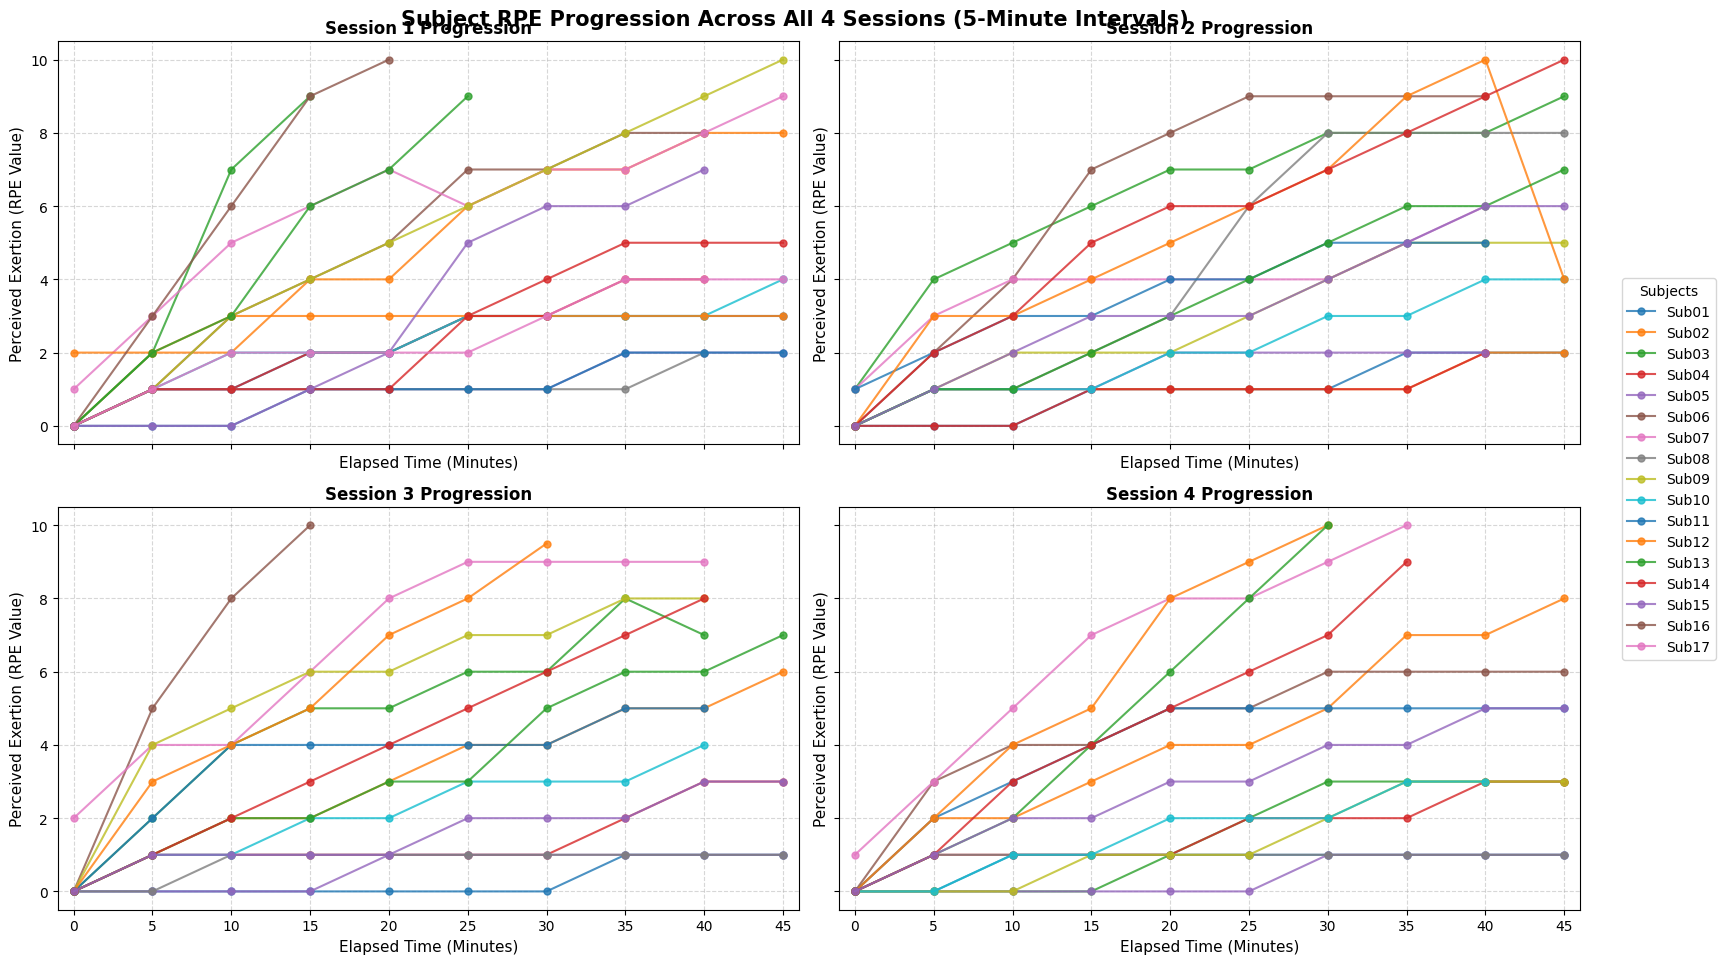

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to a 1D array for easy indexing (0 to 3)

sessions = ['Session1', 'Session2', 'Session3', 'Session4']
FORTY_FIVE_MINUTES_IN_SEC = 45 * 60  

# Get a sorted list of all unique subjects across the dataset
unique_subjects = sorted(list(set(key[0] for key in ts_data.keys())))

# Loop through each session to create its respective subplot
for idx, session_name in enumerate(sessions):
    ax = axes[idx]
    
    for sub in unique_subjects:
        key = (sub, session_name)
        if key not in ts_data:
            continue
            
        df = ts_data[key]
        
        # Clean up session target matching
        df_session = df[df['Session'].astype(str).str.strip() == session_name].copy()
        
        if df_session.empty:
            continue
            
        # Get baseline start time for this specific session
        start_unix_time = df_session['Timestamp'].min()
        
        # Calculate exact elapsed minutes
        df_session['Elapsed_Minutes'] = (df_session['Timestamp'] - start_unix_time) / 60
        
        # Filter for the first 45 minutes
        df_45min = df_session[(df_session['Elapsed_Minutes'] >= 0) & (df_session['Elapsed_Minutes'] <= 45)].copy()
        
        # Drop rows without an RPE score
        df_rpe = df_45min.dropna(subset=['RPE_Val']).copy()
        
        if not df_rpe.empty:
            # Snap elapsed minutes to the nearest 5-minute interval (0, 5, 10, ..., 45)
            df_rpe['Interval_Minutes'] = (df_rpe['Elapsed_Minutes'] / 5).round() * 5
            
            # Group by interval to get a single RPE value per 5-minute block
            df_grouped = df_rpe.groupby('Interval_Minutes')['RPE_Val'].mean().reset_index()
            df_grouped = df_grouped[df_grouped['Interval_Minutes'] <= 45]
            
            # Plot line for the subject on the current axis
            ax.plot(df_grouped['Interval_Minutes'], df_grouped['RPE_Val'], '-o', label=sub, alpha=0.8, markersize=5, linewidth=1.5)
            
    # Subplot styling
    ax.set_title(f"{session_name.replace('Session', 'Session ')} Progression", fontsize=12, fontweight='bold')
    ax.set_xticks(np.arange(0, 46, 5))
    ax.set_xlim(-1, 46)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add shared X and Y axis labels to the outer bounds
for i in range(4):
    axes[i].set_ylabel("Perceived Exertion (RPE Value)", fontsize=11)
for i in range(4):
    axes[i].set_xlabel("Elapsed Time (Minutes)", fontsize=11)

# Place a single, unified legend to the right of the subplots
handles, labels = axes[0].get_legend_handles_labels()
# Sort the legend handles/labels by subject name for clean display
if handles:
    sorted_legend = sorted(zip(labels, handles), key=lambda t: t[0])
    labels, handles = zip(*sorted_legend)
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.08, 0.5), title="Subjects")

plt.suptitle("Subject RPE Progression Across All 4 Sessions (5-Minute Intervals)", fontsize=15, fontweight='bold', y=0.96)
plt.tight_layout()
plt.show()


In [6]:
import pprint

# Pretty print the settings dictionary for Subject 1
pprint.pprint(experiment_settings['Sub01'])


          Weight  Pace
Session1     2.5    15
Session2     2.5    10
Session3     2.5     5
Session4     1.5    15


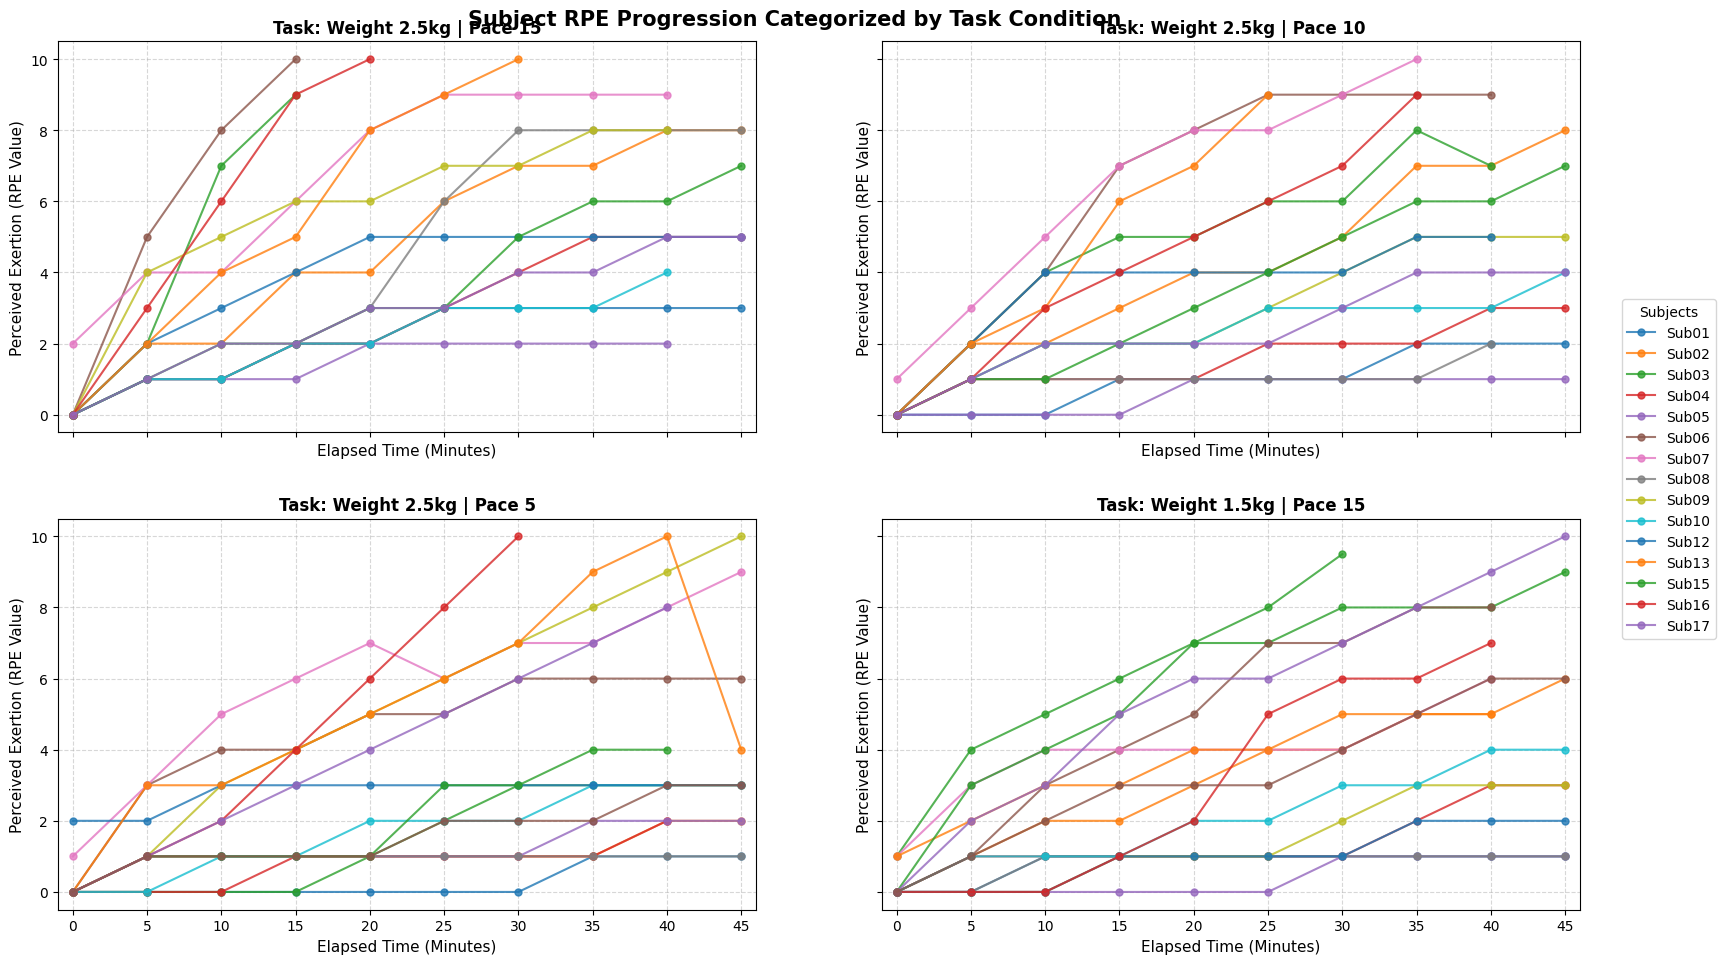

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define our 4 distinct experimental conditions (Tasks)
tasks = [
    {"Weight": 2.5, "Pace": 15},
    {"Weight": 2.5, "Pace": 10},
    {"Weight": 2.5, "Pace": 5},
    {"Weight": 1.5, "Pace": 15}
]

# Set up a 2x2 grid of subplots mapped to conditions
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

sessions_list = ['Session1', 'Session2', 'Session3', 'Session4']
unique_subjects = sorted(list(set(key[0] for key in ts_data.keys())))

# Helper function to find which session matches a specific task for a given subject
def get_matching_session(subject, target_weight, target_pace):
    if subject not in experiment_settings:
        return None
    settings = experiment_settings[subject]
    
    # CASE A: If settings is a Pandas DataFrame or Series
    if hasattr(settings, 'loc') or isinstance(settings, pd.DataFrame):
        df_set = pd.DataFrame(settings).copy()
        
        # Ensure column names are standardized to capitalized strings
        df_set.columns = [str(c).capitalize() for c in df_set.columns]
        
        # Filter rows matching our target weight and pace
        match = df_set[(df_set['Weight'] == target_weight) & (df_set['Pace'] == target_pace)]
        
        if not match.empty:
            # If 'Session' is an actual column name
            if 'Session' in match.columns:
                return str(match['Session'].values[0]).strip()
            # If Session names are inside the row Index (e.g., Row label is 'Session1')
            else:
                return str(match.index[0]).strip()
                
    # CASE B: If settings is a standard nested Python dictionary
    if isinstance(settings, dict):
        for sess in sessions_list:
            if sess in settings:
                sub_dict = settings[sess]
                if isinstance(sub_dict, dict):
                    w = sub_dict.get('Weight', sub_dict.get('weight'))
                    p = sub_dict.get('Pace', sub_dict.get('pace'))
                    if w == target_weight and p == target_pace:
                        return sess.strip()
                        
    return None

# Loop through each task and draw its subplot
for idx, task in enumerate(tasks):
    ax = axes[idx]
    w_target = task["Weight"]
    p_target = task["Pace"]
    
    for sub in unique_subjects:
        session_name = get_matching_session(sub, w_target, p_target)
        
        if not session_name:
            continue  
            
        key = (sub, session_name)
        if key not in ts_data:
            continue
            
        df = ts_data[key]
        df_session = df[df['Session'].astype(str).str.strip() == session_name].copy()
        
        if df_session.empty:
            continue
            
        # Standardize the timeline starting point
        start_unix_time = df_session['Timestamp'].min()
        df_session['Elapsed_Minutes'] = (df_session['Timestamp'] - start_unix_time) / 60
        
        # Isolate the first 45 minutes and drop NaNs
        df_45min = df_session[(df_session['Elapsed_Minutes'] >= 0) & (df_session['Elapsed_Minutes'] <= 45)].copy()
        df_rpe = df_45min.dropna(subset=['RPE_Val']).copy()
        
        if not df_rpe.empty:
            # Snap to 5-minute reporting intervals
            df_rpe['Interval_Minutes'] = (df_rpe['Elapsed_Minutes'] / 5).round() * 5
            df_grouped = df_rpe.groupby('Interval_Minutes')['RPE_Val'].mean().reset_index()
            df_grouped = df_grouped[df_grouped['Interval_Minutes'] <= 45]
            
            # Plot the continuous trend line
            ax.plot(df_grouped['Interval_Minutes'], df_grouped['RPE_Val'], '-o', label=sub, alpha=0.8, markersize=5, linewidth=1.5)
            
    # Style individual subplots
    ax.set_title(f"Task: Weight {w_target}kg | Pace {p_target}", fontsize=12, fontweight='bold')
    ax.set_xticks(np.arange(0, 46, 5))
    ax.set_xlim(-1, 46)
    ax.grid(True, linestyle="--", alpha=0.5)

# Standardized Axis Labels applied to all axes
for ax in axes:
    ax.set_ylabel("Perceived Exertion (RPE Value)", fontsize=11)
    ax.set_xlabel("Elapsed Time (Minutes)", fontsize=11)

# Generate a unified, clean side-legend from the grid elements
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    by_label = dict(zip(labels, handles))
    sorted_labels = sorted(by_label.keys())
    sorted_handles = [by_label[l] for l in sorted_labels]
    fig.legend(sorted_handles, sorted_labels, loc='center right', bbox_to_anchor=(1.08, 0.5), title="Subjects")

plt.suptitle("Subject RPE Progression Categorized by Task Condition", fontsize=15, fontweight='bold', y=0.96)
plt.tight_layout()
plt.subplots_adjust(wspace=0.18, hspace=0.22) 
plt.show()
